Nombre: [Tu nombre]
RUT: [Tu rut]
Fecha: [Fecha]

Lab 7 - Limpieza de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv("encuesta_salud.csv")
df.head()

,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa,grupo_sanguineo,region,diagnostico
0,1,56.00,86.80,1.80,124.80,231.00,77.50,B-,Araucania,Sano
1,2,69.00,72.70,1.46,104.40,148.90,102.50,A+,Biobio,Hipertension
2,3,46.00,84.20,1.50,164.50,220.30,78.30,AB+,Valparaiso,Hipertension
3,4,32.00,86.90,1.63,95.20,218.40,60.50,AB-,Araucania,Prediabetes
4,5,NaN,58.60,1.78,130.50,152.60,400.00,B-,Biobio,Sano


El dataset tiene varias filas y columnas.
Hay datos numéricos y también de texto.
Se ven algunos valores vacíos.

In [3]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                500 non-null    int64  
 1   edad              455 non-null    float64
 2   peso_kg           440 non-null    float64
 3   talla_m           500 non-null    float64
 4   presion_arterial  500 non-null    float64
 5   colesterol        460 non-null    float64
 6   glucosa           500 non-null    float64
 7   grupo_sanguineo   475 non-null    object 
 8   region            500 non-null    object 
 9   diagnostico       470 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,500.00,455.00,440.00,500.00,500.00,460.00,500.00
mean,250.50,50.18,72.44,6.76,123.15,193.66,101.81
std,144.48,18.21,14.32,28.92,29.66,34.47,47.26
min,1.00,18.00,34.80,1.33,62.20,102.60,18.60
25%,125.75,35.00,63.27,1.61,106.35,170.15,80.38
50%,250.50,50.00,72.35,1.69,120.75,193.95,97.45
75%,375.25,66.00,82.93,1.75,133.68,217.05,112.80
max,500.00,79.00,111.00,186.00,290.00,290.60,420.00


In [5]:
df['talla_m'].min()
df['talla_m'].max()

186.0

Se ven valores raros en talla, probablemente están en cm.

In [6]:
df['edad'] = df['edad'].fillna(df['edad'].mean())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].mean())

df = df.dropna()

In [7]:
df.loc[df['talla_m'] > 3, 'talla_m'] = df['talla_m'] / 100

df.isnull().sum()

id                  0
edad                0
peso_kg             0
talla_m             0
presion_arterial    0
colesterol          0
glucosa             0
grupo_sanguineo     0
region              0
diagnostico         0
dtype: int64

In [8]:
Q1 = df['presion_arterial'].quantile(0.25)
Q3 = df['presion_arterial'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['presion_arterial'] < lim_inf) | (df['presion_arterial'] > lim_sup)]
len(outliers)

14

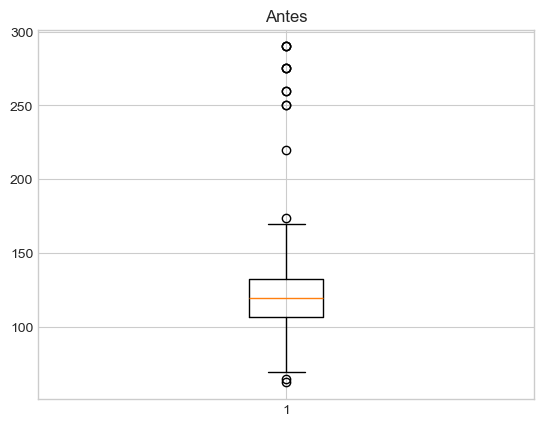

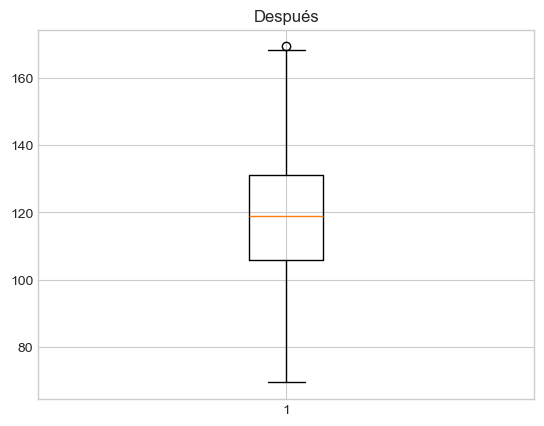

In [9]:
plt.boxplot(df['presion_arterial'])
plt.title("Antes")
plt.show()

df = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

plt.boxplot(df['presion_arterial'])
plt.title("Después")
plt.show()

In [10]:
z = np.abs(stats.zscore(df['glucosa']))
df = df[z < 3]

No siempre es bueno eliminar outliers porque pueden ser datos reales, pero aquí se hizo para limpiar.

In [11]:
cols = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']

scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])

df[cols].describe()

,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,393.00,393.00,393.00,393.00,393.00,393.00
mean,0.53,0.48,0.54,0.50,0.48,0.61
std,0.29,0.18,0.15,0.19,0.18,0.17
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.33,0.37,0.43,0.37,0.36,0.49
50%,0.53,0.48,0.54,0.50,0.49,0.62
75%,0.77,0.60,0.63,0.62,0.61,0.75
max,1.00,1.00,1.00,1.00,1.00,1.00


In [12]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df = pd.get_dummies(df, columns=['grupo_sanguineo'], drop_first=True)

In [13]:
le = LabelEncoder()
df['diagnostico_cod'] = le.fit_transform(df['diagnostico'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'Diabetes': np.int64(0),
 'Hipertension': np.int64(1),
 'Obesidad': np.int64(2),
 'Prediabetes': np.int64(3),
 'Sano': np.int64(4)}

In [14]:
print("Filas finales:", len(df))
print("Columnas finales:", len(df.columns))
print("NaN:", df.isnull().sum().sum())

Filas finales: 393
Columnas finales: 20
NaN: 0


## Reporte

### NaN
Se rellenaron algunos con promedio y otros se eliminaron.

### Outliers
Se eliminaron valores extremos.

### Normalización
Se dejó todo entre 0 y 1.

### Codificación
Se pasaron datos de texto a números.

In [17]:
df.to_csv('encuesta_salud_limpio.csv', index=False)
print('Dataset limpio guardado como encuesta_salud_limpio.csv')
print(f'Shape final: {df_final.shape}')

NameError: name 'df_final' is not defined